In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import sys, os
sys.path.append(os.path.abspath("../src"))

from binomial_model import price_option_tree, price_option_tree_no_volatility
from visualization import plot_binomial_trees
from black_scholes_merton import price_option_bsm
from greeks import delta_bsm, theta_bsm, gamma_bsm, vega_bsm, rho_bsm, delta_tree, theta_tree, gamma_tree

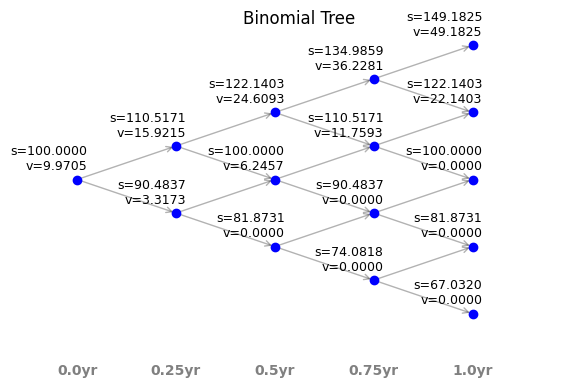

In [2]:
price, stocks, options, timeline = price_option_tree(option_type="call", exercise_style="American", s=100, k=100,
                                                sigma=0.2, T=1, N=4, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

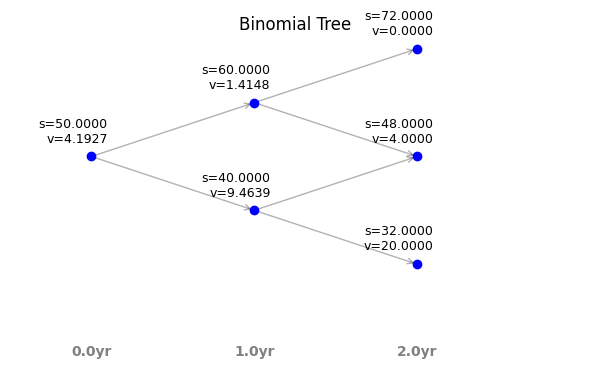

In [3]:
#figure 13.7
price, stocks, options, timeline = price_option_tree_no_volatility(option_type='put',exercise_style='European', s=50, k=52, 
                                                              up=20, down=20, T=2, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

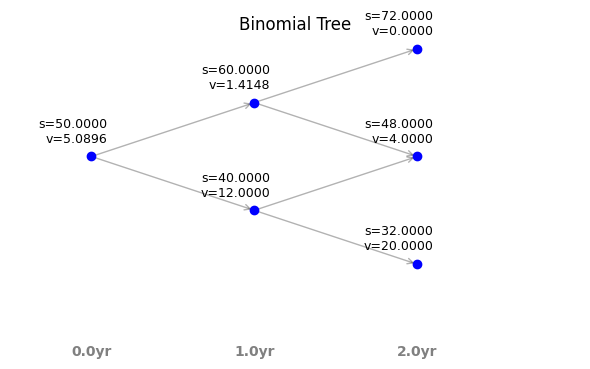

In [4]:
#figure 13.8
price, stocks, options, timeline = price_option_tree_no_volatility(option_type='put',exercise_style='American', s=50, k=52, 
                                                                     up=20, down=20, T=2, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

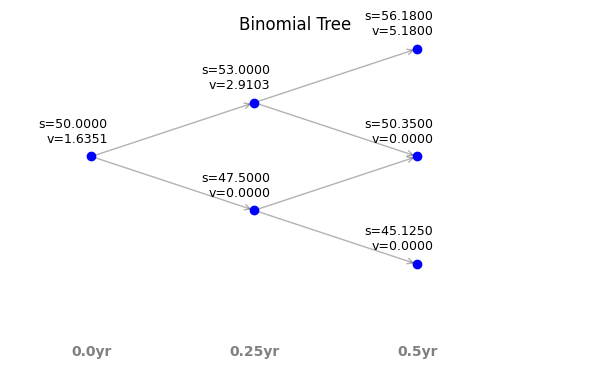

In [5]:
# practice 13.7
price, stocks, options, timeline =  price_option_tree_no_volatility(option_type='call',exercise_style='European',s=50, k=51, 
                                                                      up=6, down=5, T=0.5, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

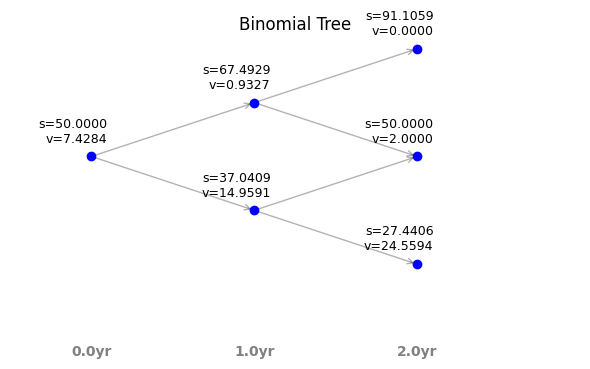

In [6]:

option_value, stocks, options, timeline = price_option_tree(option_type='put',exercise_style='American', s=50, k=52, 
                                                       sigma=0.3, T=2, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

In [7]:
# Example 15.6
print(price_option_bsm(option_type='call', exercise_style='European', s=42, k=40, T=0.5, r=0.1, q=0, sigma=0.2))
print(price_option_bsm(option_type='put', exercise_style='European', s=42, k=40, T=0.5, r=0.1, q=0, sigma=0.2))

4.759422392871532
0.8085993729000922


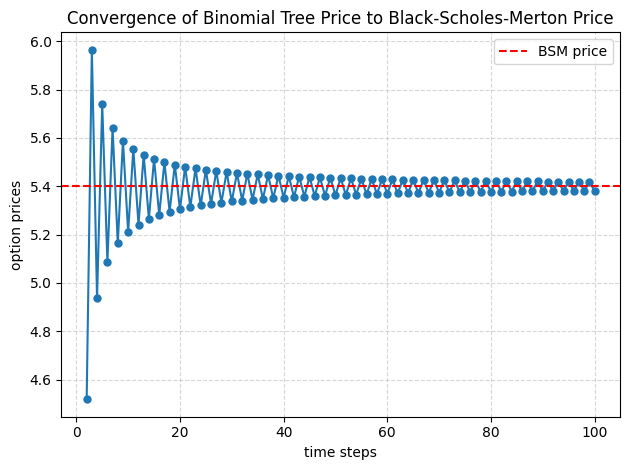

In [8]:
prices = []
time_steps = np.arange(2,101)
BSM_price = price_option_bsm(option_type='put', exercise_style='European', s=50, k=50, T=1, r=0.1, q=0, sigma=0.4)


for N in time_steps:
    price = price_option_tree(option_type="put", exercise_style="European", s=50, k=50,
                                                sigma=0.4, T=1, N=N, r=0.1, return_tree=False)
    prices.append(price)

plt.plot(time_steps, prices, marker='o', linestyle='-', ms=5)
plt.axhline(y=BSM_price, color='r', linestyle='--', label='BSM price')
plt.ylabel('option prices')
plt.xlabel('time steps')
plt.title('Convergence of Binomial Tree Price to Black-Scholes-Merton Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

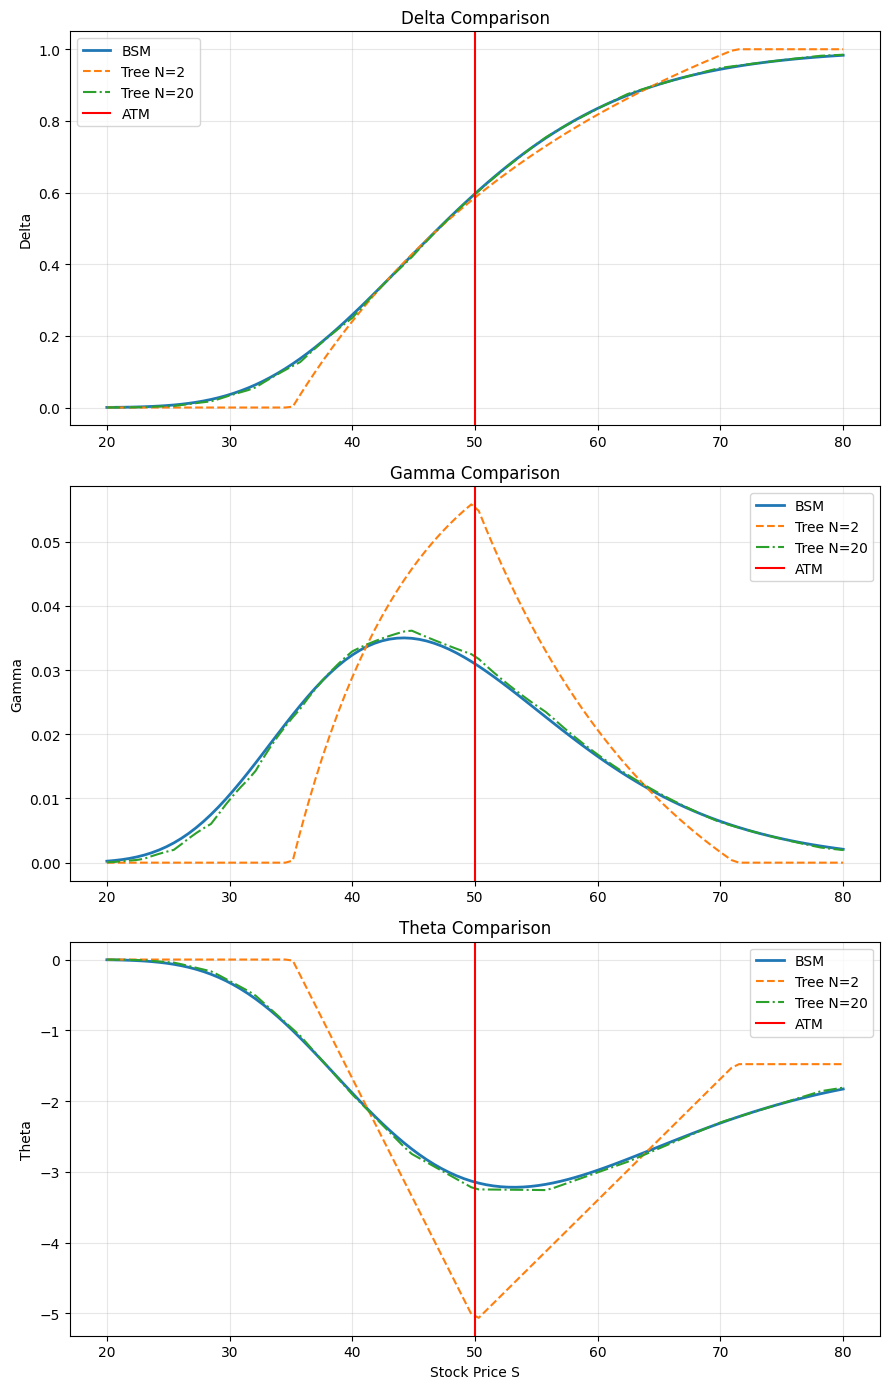

In [10]:
# Parameters
s_vals = np.linspace(20, 80, 100)
k = 50
T = 1
r = 0.03
sigma = 0.25
q = 0.0
option_type = 'call'
exercise_style = 'European'

N_small = 2
N_medium = 20

# Compute BSM Greeks
delta_bsm_vals = np.array([delta_bsm(option_type, s, k, r, sigma, T, q) for s in s_vals])
gamma_bsm_vals = np.array([gamma_bsm(s, k, r, sigma, T, q) for s in s_vals])
theta_bsm_vals = np.array([theta_bsm(option_type, s, k, r, sigma, T, q) for s in s_vals])

# Compute Tree Greeks (N=2)
delta_tree_2 = np.array([delta_tree(option_type, exercise_style, s, k, sigma, T, N_small, r, q) for s in s_vals])
gamma_tree_2 = np.array([gamma_tree(option_type, exercise_style, s, k, sigma, T, N_small, r, q) for s in s_vals])
theta_tree_2 = np.array([theta_tree(option_type, exercise_style, s, k, sigma, T, N_small, r, q) for s in s_vals])

# Compute Tree Greeks (N=20)
delta_tree_20 = np.array([delta_tree(option_type, exercise_style, s, k, sigma, T, N_medium, r, q) for s in s_vals])
gamma_tree_20 = np.array([gamma_tree(option_type, exercise_style, s, k, sigma, T, N_medium, r, q) for s in s_vals])
theta_tree_20 = np.array([theta_tree(option_type, exercise_style, s, k, sigma, T, N_medium, r, q) for s in s_vals])

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(9, 14))

# delta
axes[0].plot(s_vals, delta_bsm_vals, label='BSM', linewidth=2)
axes[0].plot(s_vals, delta_tree_2, label='Tree N=2', linestyle='--')
axes[0].plot(s_vals, delta_tree_20, label='Tree N=20', linestyle='-.')
axes[0].axvline(k, color='r', linestyle='-', label='ATM')
axes[0].set_title('Delta Comparison')
axes[0].set_ylabel('Delta')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# gamma
axes[1].plot(s_vals, gamma_bsm_vals, label='BSM', linewidth=2)
axes[1].plot(s_vals, gamma_tree_2, label='Tree N=2', linestyle='--')
axes[1].plot(s_vals, gamma_tree_20, label='Tree N=20', linestyle='-.')
axes[1].axvline(k, color='r', linestyle='-', label='ATM')
axes[1].set_title('Gamma Comparison')
axes[1].set_ylabel('Gamma')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# theta
axes[2].plot(s_vals, theta_bsm_vals, label='BSM', linewidth=2)
axes[2].plot(s_vals, theta_tree_2, label='Tree N=2', linestyle='--')
axes[2].plot(s_vals, theta_tree_20, label='Tree N=20', linestyle='-.')
axes[2].axvline(k, color='r', linestyle='-', label='ATM')
axes[2].set_title('Theta Comparison')
axes[2].set_xlabel('Stock Price S')
axes[2].set_ylabel('Theta')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()